# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [10]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json

gm = px.data.gapminder()
print(f"Loaded: {len(df)} countries")
print(gm.columns.tolist())
print(gm.head())

Loaded: 20 countries
['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap', 'iso_alpha', 'iso_num']
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


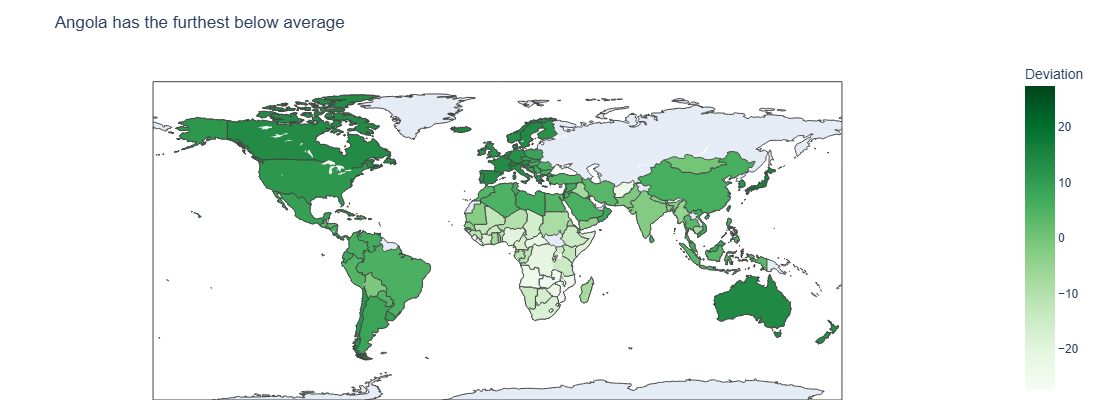

In [ ]:
# Task 1
# YOUR CODE HERE
gm_2007 = gm.loc[gm['year'] == 2007]
mean_life = gm_2007['lifeExp'].mean()
gm_2007['dev_life'] = gm_2007['lifeExp'] - mean_life

fig = px.choropleth(
    gm_2007,
    locationmode='ISO-3',
    locations='iso_alpha',
    color='dev_life',
    hover_name='country',
    hover_data={'lifeExp':':', 'dev_life':':'},
    color_continuous_scale='Greens',
    color_continuous_midpoint=0,
    fitbounds='locations',                  # clips to only the countries in the data
    labels={'dev_life': 'Deviation'},
    title='Mozambique has the furthest below average',
    height=400,
)
fig.update_layout(
    font=dict(family='Arial', size=12),
    margin=dict(l=0, r=0, t=55, b=0),
)
fig.show()


## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


### Task 2 — Design decisions

**GeoJSON source:** *(URL or description)*

**Chart type chosen** (`px.choropleth` or `px.choropleth_mapbox`) **and reason:**

*Your answer here*

**Colour scale chosen** (sequential or diverging) **and reason:**

*Your answer here*


In [80]:
# Task 2
# YOUR CODE HERE

# Load your GeoJSON
# with open('your_file.geojson', 'r') as file:
#     my_geojson = json.load(file)

# Inspect the properties to find the right featureidkey
# print(my_geojson['features'][0]['properties'])
energy_data = pd.DataFrame({
    'state_name': [
        'California', 'Texas', 'New York', 'Washington', 'Florida', 
        'Illinois', 'Pennsylvania', 'Ohio', 'Georgia', 'North Carolina', 
        'Colorado', 'Arizona', 'Michigan', 'Oregon', 'Nevada'
    ],
    'renewable_share': [45.2, 38.1, 28.4, 52.9, 12.5, 18.2, 14.1, 10.8, 15.3, 22.1, 24.3, 26.8, 11.4, 31.4, 20.2]
})
with open('../data/us-states.json', 'r', encoding='utf-8') as file:
    us_map_geojson = json.load(file)

print(us_map_geojson['features'][0]['properties'])

{'name': 'Alabama', 'density': 94.65}


In [81]:
fig = px.choropleth(
    data_frame=energy_data,
    geojson=us_map_geojson,
    locations='state_name',             # Column in your DataFrame
    featureidkey='properties.name',     # Points to the exact property path inside the internet GeoJSON
    color='renewable_share',
    color_continuous_scale='Greens',
    fitbounds='locations',              # Locks camera directly onto the mapped states
    hover_name='state_name',
    labels={'renewable_share': 'Clean Energy Share (%)'},
    title='U.S. Clean Energy Shifts: Production Distribution across 15 Major Polygons',
    height=600
)

# Step D: Apply map adjustments
fig.update_layout(
    font=dict(family='Arial', size=12),
    geo=dict(showframe=False, showcoastlines=False),
    margin=dict(l=0, r=0, t=55, b=0)
)

fig.show()